# Compliance Screening

Screen multiple Swiss companies against sanctions lists, assess risk scores,
and produce a consolidated compliance report with visualizations.

```bash
pip install vynco matplotlib seaborn
```

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import vynco

sns.set_theme(style="whitegrid", font_scale=1.1)
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

client = vynco.Client()

# Find companies to screen
TARGETS = []
for query in ["ABB", "UBS", "Novartis", "Roche", "Zurich Insurance"]:
    r = client.companies.list(query=query, page_size=1)
    if r.data.items:
        co = r.data.items[0]
        TARGETS.append({"uid": co.uid, "name": co.name})
        print(f"  Found: {co.name} ({co.uid})")

print(f"\nWill screen {len(TARGETS)} companies")

  Found: ABB SA (CHE-101.049.653)
  Found: UBS SA (CHE-101.329.561)
  Found: Novartis Overseas Investments SA (CHE-103.011.259)
  Found: Roche Finance SA (CHE-103.000.037)


  Found: Zurich Insurance Group SA (CHE-101.236.480)

Will screen 5 companies


## 1. Batch Sanctions Screening

Screen each company against global sanctions databases and collect results.

In [2]:
screening_results = []
for target in TARGETS:
    result = client.screening.screen(name=target["name"], uid=target["uid"])
    screening_results.append({
        "uid": target["uid"],
        "name": target["name"],
        "risk_level": result.data.risk_level,
        "hit_count": result.data.hit_count,
        "sources": result.data.sources_checked,
        "hits": result.data.hits,
    })
    status = "CLEAR" if result.data.hit_count == 0 else f"{result.data.hit_count} HITS"
    print(f"  [{result.data.risk_level:>8}] {target['name']:<40} {status}")

print(f"\nScreened {len(screening_results)} companies")

  [   clear] ABB SA                                   CLEAR


  [   clear] UBS SA                                   CLEAR


  [   clear] Novartis Overseas Investments SA         CLEAR


  [     low] Roche Finance SA                         1 HITS


  [     low] Zurich Insurance Group SA                1 HITS

Screened 5 companies


## 2. Screening Results Overview

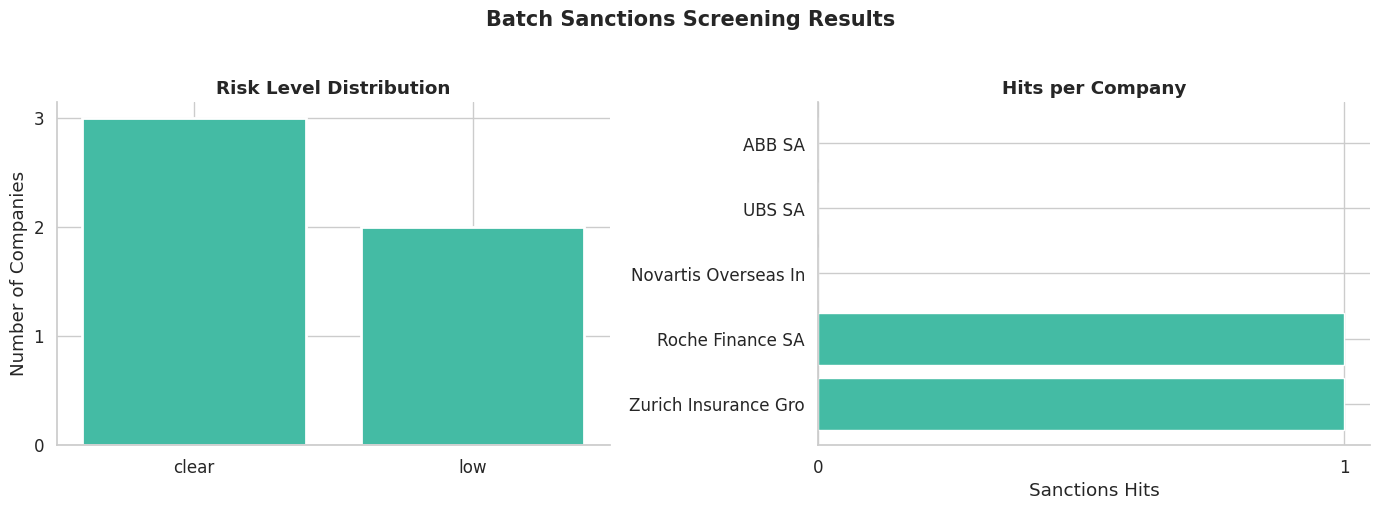

In [3]:
level_colors = {"low": "#44bba4", "medium": "#f18f01", "high": "#e94f37", "critical": "#c73e1d",
                "none": "#44bba4", "clear": "#44bba4"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Risk level distribution
levels = [r["risk_level"] for r in screening_results]
level_counts: dict[str, int] = {}
for l in levels:
    level_counts[l] = level_counts.get(l, 0) + 1

l_labels = list(level_counts.keys())
l_values = list(level_counts.values())
l_colors = [level_colors.get(l, "#999") for l in l_labels]

ax1.bar(l_labels, l_values, color=l_colors, edgecolor="white", linewidth=2)
ax1.set_ylabel("Number of Companies")
ax1.set_title("Risk Level Distribution", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Hit counts per company
names = [r["name"][:20] for r in screening_results]
hits = [r["hit_count"] for r in screening_results]
bar_colors = [level_colors.get(r["risk_level"], "#999") for r in screening_results]

ax2.barh(names[::-1], hits[::-1], color=bar_colors[::-1], edgecolor="white", linewidth=1)
ax2.set_xlabel("Sanctions Hits")
ax2.set_title("Hits per Company", fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle("Batch Sanctions Screening Results", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/screening_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. AI Risk Scores

Get detailed AI-powered risk assessments for each company and
build a comparative heatmap of risk factors.

In [4]:
risk_results = []
for target in TARGETS:
    risk = client.ai.risk_score(uid=target["uid"]).data
    risk_results.append(risk)
    print(f"  {risk.company_name:<40} Score: {risk.overall_score:>3}/100  [{risk.risk_level}]")

print(f"\nAssessed {len(risk_results)} companies")

  ABB SA                                   Score:  14/100  [low]
  UBS SA                                   Score:  14/100  [low]
  Novartis Overseas Investments SA         Score:  14/100  [low]


  Roche Finance SA                         Score:  46/100  [medium]
  Zurich Insurance Group SA                Score:  49/100  [medium]

Assessed 5 companies


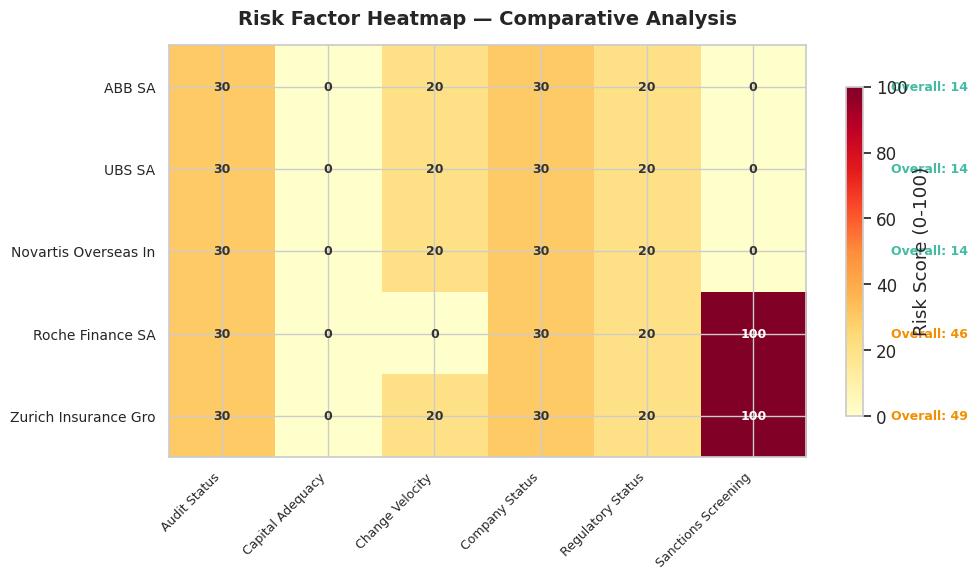

In [5]:
# Build heatmap data: companies x risk factors
all_factors = sorted({f.factor for r in risk_results for f in r.breakdown})
company_names = [r.company_name[:20] for r in risk_results]

heatmap_data = []
for r in risk_results:
    factor_map = {f.factor: f.score for f in r.breakdown}
    row = [factor_map.get(f, 0) for f in all_factors]
    heatmap_data.append(row)

fig, ax = plt.subplots(figsize=(max(10, len(all_factors) * 1.2), max(4, len(TARGETS) * 0.8 + 2)))

im = ax.imshow(heatmap_data, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(all_factors)))
ax.set_xticklabels(all_factors, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(company_names)))
ax.set_yticklabels(company_names, fontsize=10)

# Add score text in each cell
for i in range(len(company_names)):
    for j in range(len(all_factors)):
        val = heatmap_data[i][j]
        color = "white" if val > 50 else "#333"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=9,
                fontweight="bold", color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Risk Score (0-100)")

# Add overall scores on the right
for i, r in enumerate(risk_results):
    ax.text(len(all_factors) + 0.3, i, f"Overall: {r.overall_score}",
            va="center", fontsize=9, fontweight="bold",
            color=level_colors.get(r.risk_level, "#999"))

ax.set_title("Risk Factor Heatmap — Comparative Analysis",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/risk_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Compliance Dashboard

A consolidated view combining screening status and risk scores.

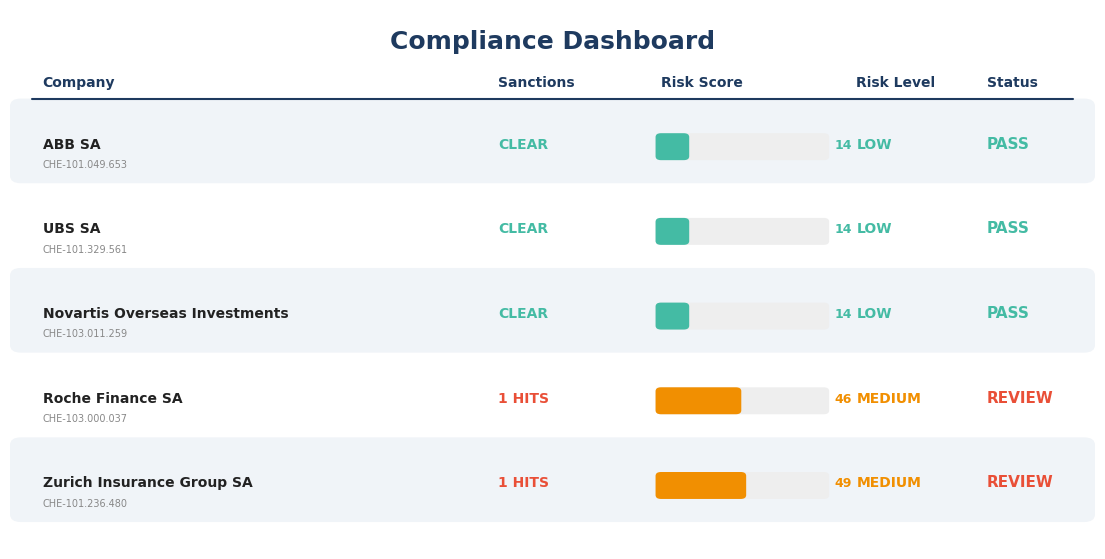

In [6]:
fig, ax = plt.subplots(figsize=(14, max(3, len(TARGETS) * 1.2 + 1)))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(TARGETS) * 1.2 + 1)
ax.axis("off")

# Title
ax.text(5, len(TARGETS) * 1.2 + 0.5, "Compliance Dashboard",
        fontsize=18, fontweight="bold", ha="center", color="#1e3a5f")

# Column headers
header_y = len(TARGETS) * 1.2
headers = [(0.3, "Company"), (4.5, "Sanctions"), (6.0, "Risk Score"),
           (7.8, "Risk Level"), (9.0, "Status")]
for x, label in headers:
    ax.text(x, header_y, label, fontsize=10, fontweight="bold", color="#1e3a5f")

ax.plot([0.2, 9.8], [header_y - 0.15, header_y - 0.15], color="#1e3a5f", linewidth=1.5)

for i, (sr, rr) in enumerate(zip(screening_results, risk_results)):
    y = header_y - 0.8 - i * 1.1

    # Alternating row background
    if i % 2 == 0:
        rect = mpatches.FancyBboxPatch((0.1, y - 0.35), 9.8, 0.9,
                                        boxstyle="round,pad=0.1",
                                        facecolor="#f0f4f8", edgecolor="none")
        ax.add_patch(rect)

    # Company name
    ax.text(0.3, y, sr["name"][:30], fontsize=10, fontweight="bold", color="#222")
    ax.text(0.3, y - 0.25, sr["uid"], fontsize=7, color="#888")

    # Sanctions hits
    hit_text = "CLEAR" if sr["hit_count"] == 0 else f"{sr['hit_count']} HITS"
    hit_color = "#44bba4" if sr["hit_count"] == 0 else "#e94f37"
    ax.text(4.5, y, hit_text, fontsize=10, fontweight="bold", color=hit_color)

    # Risk score bar
    score = rr.overall_score
    bar_color = level_colors.get(rr.risk_level, "#999")
    bar_bg = mpatches.FancyBboxPatch((6.0, y - 0.1), 1.5, 0.25,
                                      boxstyle="round,pad=0.05",
                                      facecolor="#eee", edgecolor="none")
    ax.add_patch(bar_bg)
    bar_fg = mpatches.FancyBboxPatch((6.0, y - 0.1), 1.5 * score / 100, 0.25,
                                      boxstyle="round,pad=0.05",
                                      facecolor=bar_color, edgecolor="none")
    ax.add_patch(bar_fg)
    ax.text(7.6, y, f"{score}", fontsize=9, fontweight="bold", color=bar_color)

    # Risk level
    ax.text(7.8, y, rr.risk_level.upper(), fontsize=10, fontweight="bold", color=bar_color)

    # Overall status
    if sr["hit_count"] == 0 and rr.risk_level in ("low", "none", "clear"):
        status, s_color = "PASS", "#44bba4"
    elif rr.risk_level in ("high", "critical") or sr["hit_count"] > 0:
        status, s_color = "REVIEW", "#e94f37"
    else:
        status, s_color = "MONITOR", "#f18f01"
    ax.text(9.0, y, status, fontsize=11, fontweight="bold", color=s_color)

plt.savefig(f"{FIG_DIR}/compliance_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## 5. Company Fingerprints Comparison

Compare the fingerprints of screened companies side by side.

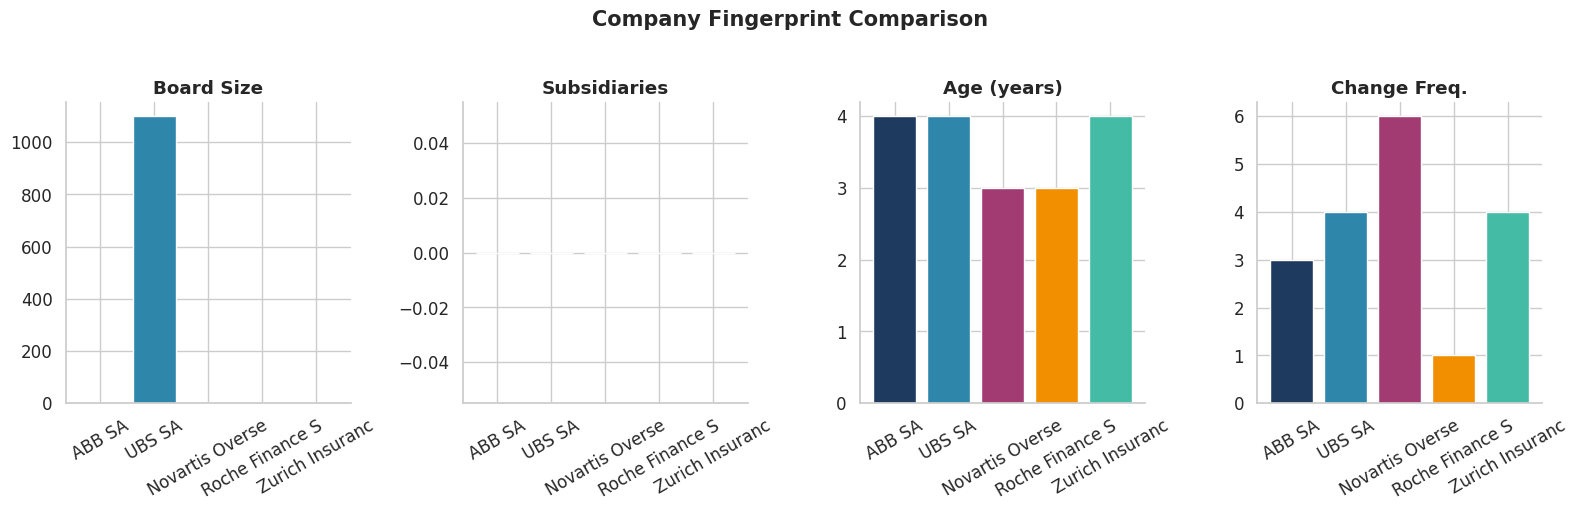

In [7]:
fingerprints = []
for target in TARGETS:
    fp = client.companies.fingerprint(target["uid"]).data
    fingerprints.append(fp)

# Compare key metrics
metrics = ["board_size", "subsidiary_count", "company_age", "change_frequency"]
metric_labels = ["Board Size", "Subsidiaries", "Age (years)", "Change Freq."]

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))
fp_names = [fp.name[:15] for fp in fingerprints]
bar_colors = ["#1e3a5f", "#2e86ab", "#a23b72", "#f18f01", "#44bba4"]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [getattr(fp, metric, 0) or 0 for fp in fingerprints]
    axes[idx].bar(fp_names, values, color=bar_colors[:len(fp_names)],
                  edgecolor="white", linewidth=1)
    axes[idx].set_title(label, fontweight="bold")
    axes[idx].spines[["top", "right"]].set_visible(False)
    axes[idx].tick_params(axis="x", rotation=30)

plt.suptitle("Company Fingerprint Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fingerprint_comparison.png", dpi=150, bbox_inches="tight")
plt.show()